<a href="https://colab.research.google.com/github/arzmtva/my-data-analysis/blob/main/Practical_5_Classification_Threshold.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score,
    precision_recall_curve,
    auc
)

In [2]:
data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="target")

print("Размер данных:", X.shape)
print("\nКоличество классов:")
print(y.value_counts())

print("\nПервые 5 строк:")
display(X.head())

Размер данных: (569, 30)

Количество классов:
target
1    357
0    212
Name: count, dtype: int64

Первые 5 строк:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [3]:
y = 1 - y

print("Количество классов после преобразования:")
print(y.value_counts())

print("\nТеперь:")
print("0 = benign")
print("1 = malignant")

Количество классов после преобразования:
target
0    357
1    212
Name: count, dtype: int64

Теперь:
0 = benign
1 = malignant


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Размер обучающей выборки:", X_train.shape)
print("Размер тестовой выборки:", X_test.shape)

Размер обучающей выборки: (455, 30)
Размер тестовой выборки: (114, 30)


In [5]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Масштабирование завершено.")

Масштабирование завершено.


In [6]:
model = LogisticRegression(max_iter=10000, random_state=42)

model.fit(X_train_scaled, y_train)

print("Модель обучена.")

Модель обучена.


In [7]:
y_proba = model.predict_proba(X_test_scaled)[:, 1]

print("Первые 10 вероятностей:")
print(y_proba[:10])

Первые 10 вероятностей:
[3.64568116e-04 9.99999989e-01 4.25679471e-02 5.76187322e-01
 5.09155489e-01 6.16001620e-04 7.61534086e-01 1.01217174e-03
 5.68725516e-04 1.07675795e-02]


In [8]:
threshold_default = 0.5

y_pred_default = (y_proba >= threshold_default).astype(int)

print("Порог:", threshold_default)
print("\nПервые 20 предсказаний:")
print(y_pred_default[:20])

Порог: 0.5

Первые 20 предсказаний:
[0 1 0 1 1 0 1 0 0 0 1 0 1 0 0 0 0 0 0 0]


In [9]:
print("Метрики при пороге 0.5")
print("-----------------------")

print("Accuracy :", accuracy_score(y_test, y_pred_default))
print("Precision:", precision_score(y_test, y_pred_default))
print("Recall   :", recall_score(y_test, y_pred_default))
print("F1-score :", f1_score(y_test, y_pred_default))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_default))

Метрики при пороге 0.5
-----------------------
Accuracy : 0.9649122807017544
Precision: 0.975
Recall   : 0.9285714285714286
F1-score : 0.9512195121951219

Confusion Matrix:
[[71  1]
 [ 3 39]]


ROC-AUC: 0.996031746031746


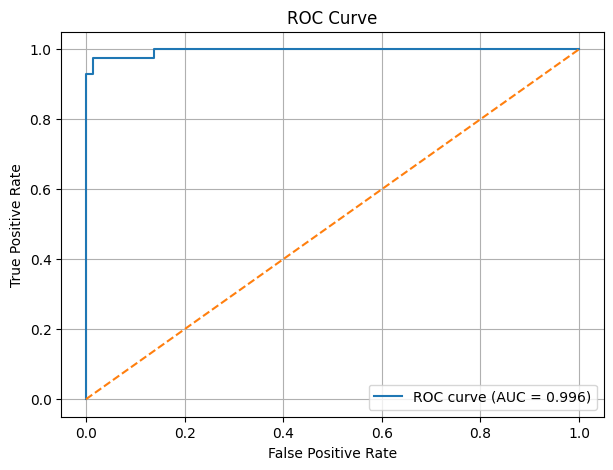

In [10]:
fpr, tpr, roc_thresholds = roc_curve(y_test, y_proba)

roc_auc = roc_auc_score(y_test, y_proba)

print("ROC-AUC:", roc_auc)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid()
plt.show()

PR-AUC: 0.994214569817921


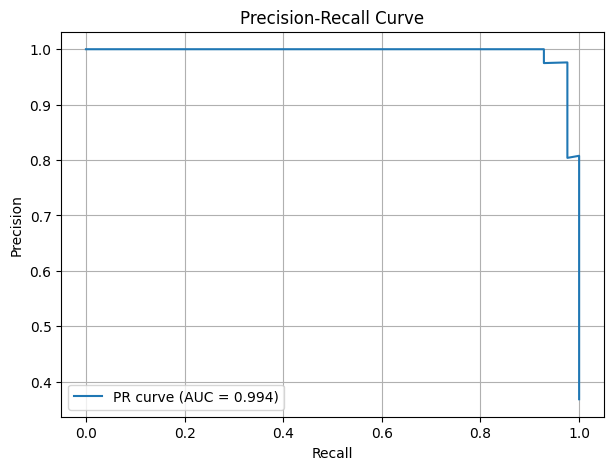

In [11]:
precision, recall, pr_thresholds = precision_recall_curve(
    y_test,
    y_proba
)

pr_auc = auc(recall, precision)

print("PR-AUC:", pr_auc)

plt.figure(figsize=(7, 5))
plt.plot(recall, precision, label=f"PR curve (AUC = {pr_auc:.3f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.grid()
plt.show()

PR-AUC: 0.994214569817921


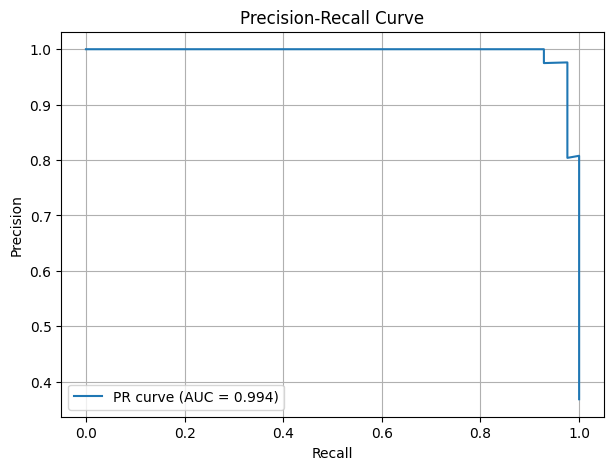

In [20]:
precision, recall, pr_thresholds = precision_recall_curve(
    y_test,
    y_proba
)

pr_auc = auc(recall, precision)

print("PR-AUC:", pr_auc)

plt.figure(figsize=(7, 5))
plt.plot(
    recall,
    precision,
    label=f"PR curve (AUC = {pr_auc:.3f})"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.grid()
plt.show()

In [12]:
thresholds_to_check = np.arange(0.10, 0.91, 0.05)

results = []

for threshold in thresholds_to_check:
    y_pred = (y_proba >= threshold).astype(int)

    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()

    results.append({
        "Threshold": threshold,
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1": f1_score(y_test, y_pred, zero_division=0),
        "FP": fp,
        "FN": fn
    })

threshold_table = pd.DataFrame(results)

display(threshold_table.round(3))

,Threshold,Precision,Recall,F1,FP,FN
0,0.10,0.891,0.976,0.932,5,1
1,0.15,0.911,0.976,0.943,4,1
2,0.20,0.911,0.976,0.943,4,1
3,0.25,0.976,0.976,0.976,1,1
4,0.30,0.976,0.976,0.976,1,1
5,0.35,0.976,0.952,0.964,1,2
6,0.40,0.976,0.952,0.964,1,2
7,0.45,0.976,0.952,0.964,1,2
8,0.50,0.975,0.929,0.951,1,3
9,0.55,1.000,0.929,0.963,0,3


In [13]:
candidates = threshold_table[
    threshold_table["Recall"] >= 0.95
].copy()

print("Пороги с Recall >= 0.95:")
display(candidates.round(3))

Пороги с Recall >= 0.95:


,Threshold,Precision,Recall,F1,FP,FN
0,0.10,0.891,0.976,0.932,5,1
1,0.15,0.911,0.976,0.943,4,1
2,0.20,0.911,0.976,0.943,4,1
3,0.25,0.976,0.976,0.976,1,1
4,0.30,0.976,0.976,0.976,1,1
5,0.35,0.976,0.952,0.964,1,2
6,0.40,0.976,0.952,0.964,1,2
7,0.45,0.976,0.952,0.964,1,2


In [14]:
best_row = candidates.sort_values(
    by="Precision",
    ascending=False
).iloc[0]

best_threshold = best_row["Threshold"]

print("Выбранный порог:", best_threshold)
print("Precision:", best_row["Precision"])
print("Recall:", best_row["Recall"])
print("F1:", best_row["F1"])
print("FP:", int(best_row["FP"]))
print("FN:", int(best_row["FN"]))

Выбранный порог: 0.25000000000000006
Precision: 0.9761904761904762
Recall: 0.9761904761904762
F1: 0.9761904761904762
FP: 1
FN: 1


In [15]:
y_pred_tuned = (y_proba >= best_threshold).astype(int)

print("Новый порог:", best_threshold)
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_tuned))

Новый порог: 0.25000000000000006

Confusion Matrix:
[[71  1]
 [ 1 41]]


In [16]:
comparison = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score"],

    "Threshold 0.5": [
        accuracy_score(y_test, y_pred_default),
        precision_score(y_test, y_pred_default),
        recall_score(y_test, y_pred_default),
        f1_score(y_test, y_pred_default)
    ],

    f"Threshold {best_threshold:.2f}": [
        accuracy_score(y_test, y_pred_tuned),
        precision_score(y_test, y_pred_tuned),
        recall_score(y_test, y_pred_tuned),
        f1_score(y_test, y_pred_tuned)
    ]
})

display(comparison.round(3))

,Metric,Threshold 0.5,Threshold 0.25
0,Accuracy,0.965,0.982
1,Precision,0.975,0.976
2,Recall,0.929,0.976
3,F1-score,0.951,0.976


In [17]:
cm_default = confusion_matrix(y_test, y_pred_default)
tn_d, fp_d, fn_d, tp_d = cm_default.ravel()

cm_tuned = confusion_matrix(y_test, y_pred_tuned)
tn_t, fp_t, fn_t, tp_t = cm_tuned.ravel()

comparison_errors = pd.DataFrame({
    "Metric": ["False Positive (FP)", "False Negative (FN)"],
    "Threshold 0.5": [fp_d, fn_d],
    f"Threshold {best_threshold:.2f}": [fp_t, fn_t]
})

display(comparison_errors)

,Metric,Threshold 0.5,Threshold 0.25
0,False Positive (FP),1,1
1,False Negative (FN),3,1


В данной практической работе была обучена модель Logistic Regression для бинарной классификации на датасете Breast Cancer Wisconsin. Вместо бинарных предсказаний были получены вероятности классов с помощью predict_proba().

Для оценки качества модели были построены ROC-кривая и Precision-Recall кривая, а также рассчитаны ROC-AUC и PR-AUC.

Стандартный порог классификации 0.5 был изменён, поскольку в данной задаче ложноотрицательная ошибка (FN) является более опасной, чем ложноположительная ошибка (FP). Пропуск злокачественного случая может иметь более серьёзные последствия, поэтому при выборе порога приоритет был отдан высокому Recall.

После сравнения различных порогов был выбран порог [ВСТАВЬ СВОЙ ПОРОГ]. При этом Recall составил [ВСТАВЬ], а количество FN изменилось с [ВСТАВЬ] до [ВСТАВЬ].

Таким образом, изменение порога позволило адаптировать модель под стоимость ошибок. Несмотря на возможное увеличение количества ложноположительных результатов, новый порог позволяет лучше выявлять положительные случаи и снижает риск пропуска злокачественных опухолей.

In [18]:
y_proba = model.predict_proba(X_test_scaled)[:, 1]

In [19]:
plt.show()